# Stanford CME 241 (Winter 2026) - Assignment 2

**Due: Friday, February 13 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):*

https://github.com/my-username/my-repo/assignment-file-name.ipynb

*Group members (replace below names with people in your group):*
- Mahmood Alhusseini
- Michael Sun
- Person 3

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1: Job-Hopping and Wages-Utility-Maximization (Led by ______)

You are a worker who starts every day either employed or unemployed. If you start your day employed, you work on your job for the day (one of $n$ jobs, as elaborated later) and you get to earn the wage of the job for the day. However, at the end of the day, you could lose your job with probability $\alpha \in [0,1]$, in which case you start the next day unemployed. If at the end of the day, you do not lose your job (with probability $1-\alpha$), then you will start the next day with the same job (and hence, the same daily wage).

On the other hand, if you start your day unemployed, then you will be randomly offered one of $n$ jobs with daily wages $w_1, w_2, \ldots w_n \in \mathbb{R}^+$ with respective job-offer probabilities $p_1, p_2, \ldots p_n \in [0,1]$ (with $\sum_{i=1}^n p_i = 1$). You can choose to either accept or decline the offered job. If you accept the job offer, your day progresses exactly like the **employed-day** described above (earning the day's job wage and possibly (with probability $\alpha$) losing the job at the end of the day). However, if you decline the job offer, you spend the day unemployed, receive the unemployment wage $w_0 \in \mathbb{R}^+$ for the day, and start the next day unemployed.

The problem is to identify the optimal choice of accepting or rejecting any of the job offers the worker receives, in a manner that maximizes the infinite-horizon **Expected Discounted-Sum of Wages Utility**. Assume the daily discount factor for wages (employed or unemployed) is $\gamma \in [0,1])$. Assume Wages Utility function to be $U(w) = \log(w)$ for any wage amount $w \in \mathbb{R}^+$. The goal is to maximize:

$$
\mathbb{E}\left[\sum_{u=t}^\infty \gamma^{u-t} \cdot \log(w_{i_u})\right]
$$

at the start of a given day $t$ ($w_{i_u}$ is the wage earned on day $u$, $0 \leq i_u \leq n$ for all $u \geq t$).

---

### Subquestions

#### Part (A): MDP Modeling

Express the job-hopping problem as an MDP using clear mathematical notation by defining the following components:

1. **State Space**: Define the possible states of the MDP.
2. **Action Space**: Specify the actions available to the worker at each state.
3. **Transition Function**: Describe the probabilities of transitioning between states for each action.
4. **Reward Function**: Specify the reward associated with the states and transitions.
5. **Bellman Optimality Equation**: Write the Bellman Optimality Equation customized for this MDP.

---

#### Part (B): Python Implementation

Write Python code that:

1. Solves the Bellman Optimality Equation (hence, solves for the **Optimal Value Function** and the **Optimal Policy**) with a numerical iterative algorithm.
2. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

*Note*: For this problem, write the algorithm from scratch without using any prebuilt MDP/DP libraries or code.

---

#### Part (C): Visualization and Analysis

1. Plot the **Optimal Value Function** as a function of the state for a specific set of parameters ($n$, $w_1, \ldots, w_n$, $p_1, \ldots, p_n$, $\alpha$, $\gamma$, $w_0$).
2. Include these graphs in your submission.

---

#### Part (D): Observations

1. What patterns do you observe in the **Optimal Policy** as you vary the parameters $n$, $\alpha$, and $\gamma$?
2. Provide a brief discussion of your findings.

---

### Part (A) Answer

<span style="color:red">
State space: $S = \{(E_i, i)\}$ for all $i$ from 0 to n inclusive, where (1,i) means a person is employed at job i, while (0,i) means a person has received an offer to work job i.

Action space: If $E_i = 1$, action space is work the job (in other words, accept the job, so A). If $E_i = 0$, action space is accept the job or reject the job (A, R).

Transition function: for all i, $P((1,i)|(1,i), A) = 1 - \alpha$.
$P((0,j)|(1,i), A) = \alpha * p_j$.
$P((1,i)|(0,i), A) = (1-\alpha)$.
$P((0,j)|(0,i), A) = \alpha * p_j$.
$P((0,j)|(0,i), R) = p_j$.

$R((1,i)|(1,i), A) = log(w_i)$
$R((0,j)|(1,i), A) = log(w_i)$.
$R((1,i)|(0,i), A) = log(w_i)$.
$R((0,j)|(0,i), A) = log(w_i)$.
$R((0,j)|(0,i), R) = log(w_0)$.

Bellman Optimality Equation

$V^{(i+1)}(s) = max_a[R(s,a) + \gamma \sum_{s'}P(s'|s,a)V^{(i)}(s')]$




</span>

### Part (B) Answer

In [ ]:
from ast import parse
import math
from collections import defaultdict
# fill in with Python code
n = 10 # int
w = []
p = {}
alpha = 0.1
max_iter = 100
gamma = 0.9

def mdp_job_hop(n, w, p, alpha = 0.1, max_iter = 100, gamma = 0.9):
  trans = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
  V = defaultdict(float)
  best_policy = {}

  for i in range(1, n+1):
    trans[(1,i)][(1,i)]["A"] = 1 - alpha
    trans[(0,i)][(1,i)]["A"] = 1 - alpha

    for j in range(1,n+1):
      trans[(1,i)][(0,j)]["A"] = alpha * p[j]
      trans[(0,i)][(0,j)]["A"] = alpha * p[j]
      trans[(0,i)][(0,j)]["R"] = p[j]

  for iter in range(1,max_iter):
    prev_v = defaultdict(float, V)
    for i in range(1, n+1):
      V[(1,i)] = math.log(w[i]) + gamma * (trans[(1,i)][(1,i)]["A"]*prev_v[(1,i)] +
      sum(trans[(1,i)][(0,j)]["A"]*prev_v[(0,j)] for j in range(1,n+1)))

      V_0_accept = math.log(w[i]) + gamma * (trans[(0,i)][(1,i)]["A"]*prev_v[(1,i)] +
      sum(trans[(0,i)][(0,j)]["A"]*prev_v[(0,j)] for j in range(1,n+1)))

      V_0_reject = math.log(w[0]) + gamma * sum(trans[(0,i)][(0,j)]["R"]*prev_v[(0,j)] for j in range(1,n+1))

      V[(0, i)] = max(V_0_accept, V_0_reject)
      if V_0_accept > V_0_reject:
        best_policy[(0,i)] = "A"
      else:
        best_policy[(0,i)] = "R"

  return V, best_policy


### Part (C) Answer

<span style="color:red">*fill in*</span>

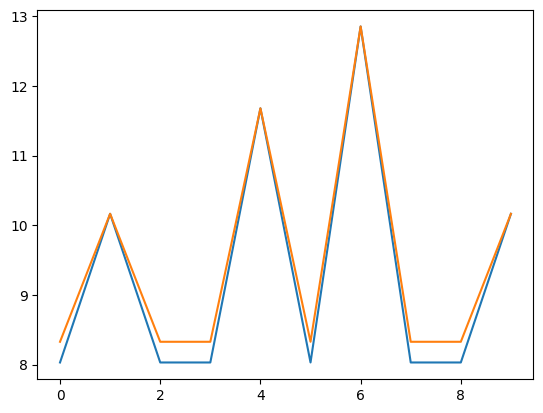

In [ ]:
n = 10
w = [1,2,3,2,2,4,2,5,2,2,3]
p = [0, 0.175, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.3, 0.05, 0.025]
V_res, best_policies = mdp_job_hop(n, w, p)

v_accept_list = []
v_reject_list = []

for i in range(1, n+1):
  v_accept = V_res[(1,i)]
  v_accept_list.append(v_accept)
  v_reject = V_res[(0,i)]
  v_reject_list.append(v_reject)

plt.plot(v_accept_list)
plt.plot(v_reject_list)
plt.show()



### Part (D) Answer

<span style="color:red">*fill in*</span>

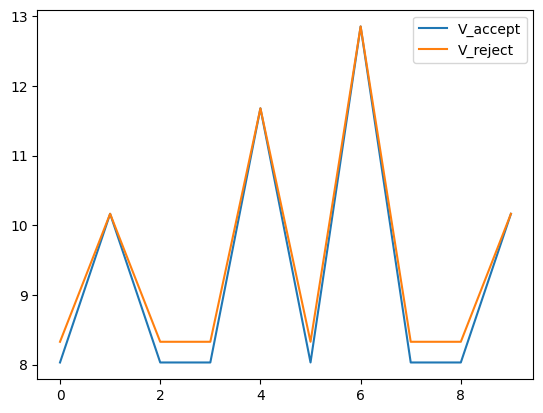

{(0, 1): 'R', (0, 2): 'A', (0, 3): 'R', (0, 4): 'R', (0, 5): 'A', (0, 6): 'R', (0, 7): 'A', (0, 8): 'R', (0, 9): 'R', (0, 10): 'A'}


In [ ]:
n = 10
w = [1,2,3,2,2,4,2,5,2,2,3]
p = [0, 0.175, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.3, 0.05, 0.025]
V_res, best_policies = mdp_job_hop(n, w, p)

v_accept_list = []
v_reject_list = []

for i in range(1, n+1):
  v_accept = V_res[(1,i)]
  v_accept_list.append(v_accept)
  v_reject = V_res[(0,i)]
  v_reject_list.append(v_reject)

plt.plot(v_accept_list, label="V_accept")
plt.plot(v_reject_list, label="V_reject")
plt.legend()
plt.show()
print(best_policies)


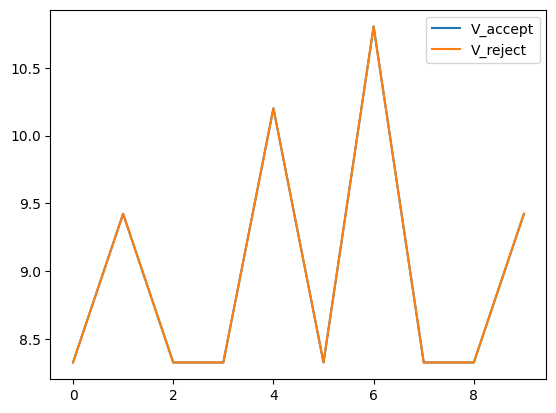

{(0, 1): 'A', (0, 2): 'A', (0, 3): 'A', (0, 4): 'A', (0, 5): 'A', (0, 6): 'A', (0, 7): 'A', (0, 8): 'A', (0, 9): 'A', (0, 10): 'A'}


In [ ]:
n = 10
w = [1,2,3,2,2,4,2,5,2,2,3]
p = [0, 0.175, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.3, 0.05, 0.025]
alpha = 0.3
max_iter = 100
gamma = 0.9
V_res, best_policies = mdp_job_hop(n, w, p, alpha)

v_accept_list = []
v_reject_list = []

for i in range(1, n+1):
  v_accept = V_res[(1,i)]
  v_accept_list.append(v_accept)
  v_reject = V_res[(0,i)]
  v_reject_list.append(v_reject)

plt.plot(v_accept_list, label="V_accept")
plt.plot(v_reject_list, label="V_reject")
plt.legend()
plt.show()
print(best_policies)


I noticed that when alpha is increased from 0.1 to 0.3 (higher probability of losing job), optimal policy shifts more towards accepting the job.

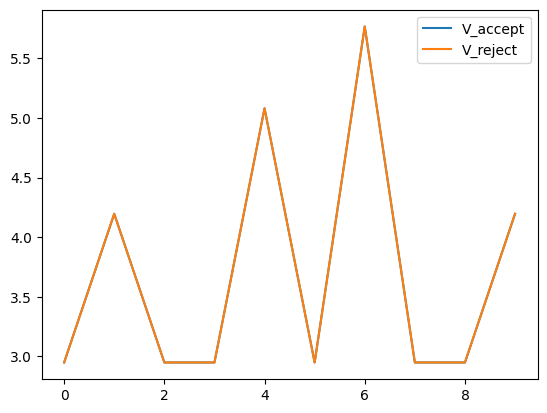

{(0, 1): 'A', (0, 2): 'A', (0, 3): 'A', (0, 4): 'A', (0, 5): 'A', (0, 6): 'A', (0, 7): 'A', (0, 8): 'A', (0, 9): 'A', (0, 10): 'A'}


In [ ]:
n = 10
w = [1,2,3,2,2,4,2,5,2,2,3]
p = [0, 0.175, 0.05, 0.05, 0.05, 0.1, 0.1, 0.1, 0.3, 0.05, 0.025]
alpha = 0.1
max_iter = 100
gamma = 0.75
V_res, best_policies = mdp_job_hop(n, w, p, alpha, max_iter, gamma)

v_accept_list = []
v_reject_list = []

for i in range(1, n+1):
  v_accept = V_res[(1,i)]
  v_accept_list.append(v_accept)
  v_reject = V_res[(0,i)]
  v_reject_list.append(v_reject)

plt.plot(v_accept_list, label="V_accept")
plt.plot(v_reject_list, label="V_reject")
plt.legend()
plt.show()
print(best_policies)

A decrease in the discount factor from 0.9 to 0.75 also results in optimal policy shifting towards accepting the job. This is expected as a decrease in the discount factor means future rewards (in this case future wages) are smaller in terms of present value, so it makes more sense to obtain a wage earlier (by accepting the job) instead of waiting for a higher paying job.

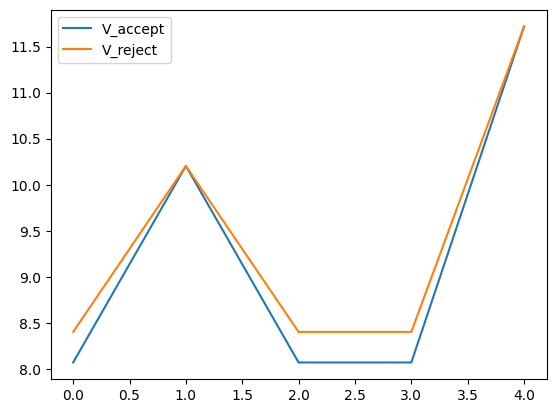

{(0, 1): 'R', (0, 2): 'A', (0, 3): 'R', (0, 4): 'R', (0, 5): 'A'}


In [ ]:
# change n to 5
n = 5
w = [1,2,3,2,2,4]
p = [0, 0.35, 0.15, 0.2, 0.1, 0.2]
alpha = 0.1
max_iter = 100
gamma = 0.9
V_res, best_policies = mdp_job_hop(n, w, p)

v_accept_list = []
v_reject_list = []

for i in range(1, n+1):
  v_accept = V_res[(1,i)]
  v_accept_list.append(v_accept)
  v_reject = V_res[(0,i)]
  v_reject_list.append(v_reject)

plt.plot(v_accept_list, label="V_accept")
plt.plot(v_reject_list, label="V_reject")
plt.legend()
plt.show()
print(best_policies)


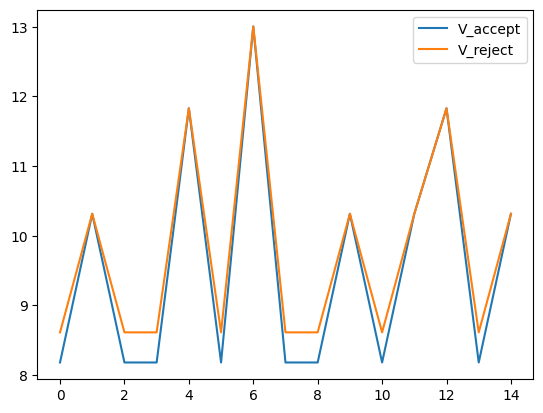

{(0, 1): 'R', (0, 2): 'A', (0, 3): 'R', (0, 4): 'R', (0, 5): 'A', (0, 6): 'R', (0, 7): 'A', (0, 8): 'R', (0, 9): 'R', (0, 10): 'A', (0, 11): 'R', (0, 12): 'A', (0, 13): 'A', (0, 14): 'R', (0, 15): 'A'}


In [ ]:
# change n to 15
n = 15
w = [1,2,3,2,2,4,2,5,2,2,3, 2, 3, 4, 2, 3]
p = [0, 0.175, 0.05, 0.05, 0.05, 0.1, 0.05, 0.05, 0.2, 0.05, 0.025, 0.05, 0.05, 0.05, 0.025, 0.025]
alpha = 0.1
max_iter = 100
gamma = 0.9
V_res, best_policies = mdp_job_hop(n, w, p)

v_accept_list = []
v_reject_list = []

for i in range(1, n+1):
  v_accept = V_res[(1,i)]
  v_accept_list.append(v_accept)
  v_reject = V_res[(0,i)]
  v_reject_list.append(v_reject)

plt.plot(v_accept_list, label="V_accept")
plt.plot(v_reject_list, label="V_reject")
plt.legend()
plt.show()
print(best_policies)

I also varied n by changing the number of jobs (increasing from 10 to 15, as well as decreasing to 5). I didn't observe a clear pattern in terms of how the optimal policy changed (in fact at many states the optimal policy stayed the same). I felt the optimal policy would be more affected by the wages and probabilities of each job (and how these would change as we varied the number of jobs).

## Question 2: Two-Stores Inventory Control (Led by ______)

We extend the capacity-constrained inventory example implemented in [rl/chapter3/simple_inventory_mdp_cap.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/chapter3/simple_inventory_mdp_cap.py) as a `FiniteMarkovDecisionProcess` (the Finite MDP model for the capacity-constrained inventory example is described in detail in Chapters 1 and 2 of the RLForFinanceBook). Here we assume that we have two different stores, each with their own separate capacities $C_1$ and $C_2$, their own separate Poisson probability distributions of demand (with means $\lambda_1$ and $\lambda_2$), their own separate holding costs $h_1$ and $h_2$, and their own separate stockout costs $p_1$ and $p_2$. At 6pm upon stores closing each evening, each store can choose to order inventory from a common supplier (as usual, ordered inventory will arrive at the store 36 hours later). We are also allowed to transfer inventory from one store to another, and any such transfer happens overnight, i.e., will arrive by 6am next morning (since the stores are fairly close to each other). Note that the orders are constrained such that following the orders on each evening, each store's inventory position (sum of on-hand inventory and on-order inventory) cannot exceed the store's capacity (this means the action space is constrained to be finite). Each order made to the supplier incurs a fixed transportation cost of $K_1$ (fixed-cost means the cost is the same no matter how many units of non-zero inventory a particular store orders). Moving any non-zero inventory between the two stores incurs a fixed transportation cost of $K_2$.

Model this as a derived class of `FiniteMarkovDecisionProcess` much like we did for `SimpleInventoryMDPCap` in the code repo. Set up instances of this derived class for different choices of the problem parameters (capacities, costs etc.), and determine the Optimal Value Function and Optimal Policy by invoking the function `value_iteration` (or `policy_iteration`) from file [rl/dynamic_programming.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/dynamic_programming.py).

Analyze the obtained Optimal Policy and verify that it makes intuitive sense as a function of the problem parameters.

In [ ]:
!pip install git+https://github.com/mikes888/RL-book

  Cloning https://github.com/mikes888/RL-book to /tmp/pip-req-build-cxo0jgf2
  Running command git clone --filter=blob:none --quiet https://github.com/mikes888/RL-book /tmp/pip-req-build-cxo0jgf2
  Resolved https://github.com/mikes888/RL-book to commit df0933ef74d12e8a3ec42242d176d8c4d2dfad92
  Preparing metadata (setup.py) ... done
  Created wheel for rl-book: filename=rl_book-0.0.1-py3-none-any.whl size=45392 sha256=c9a0264330abce1ab410013e37b70621beb203c52d37c13fe63298549783e0f3
  Stored in directory: /tmp/pip-ephem-wheel-cache-x2ygo0gh/wheels/3b/46/34/5a1742512d577eba6720f8c95a0438a2b677711b68132e0828
Successfully built rl-book


In [ ]:
from dataclasses import dataclass
from pprint import pprint
from typing import Dict, Mapping, Tuple

from rl.distribution import Categorical
from rl.dynamic_programming import policy_iteration_result, value_iteration_result
from rl.markov_decision_process import FiniteMarkovDecisionProcess
from scipy.stats import poisson


@dataclass(frozen=True)
class TwoStoreInventoryState:
    on_hand_1: int
    on_hand_2: int
    on_order_1: int
    on_order_2: int

    def inventory_position_1(self) -> int:
        return self.on_hand_1 + self.on_order_1

    def inventory_position_2(self) -> int:
        return self.on_hand_2 + self.on_order_2


@dataclass(frozen=True)
class TwoStoreAction:
    order_1: int
    order_2: int
    # transfer > 0: units moved from store 1 to store 2
    # transfer < 0: units moved from store 2 to store 1
    transfer: int


TwoStoreMapping = Mapping[
    TwoStoreInventoryState,
    Mapping[TwoStoreAction, Categorical[Tuple[TwoStoreInventoryState, float]]]
]


class TwoStoreInventoryMDP(FiniteMarkovDecisionProcess[TwoStoreInventoryState, TwoStoreAction]):
    def __init__(
        self,
        capacity_1: int,
        capacity_2: int,
        poisson_lambda_1: float,
        poisson_lambda_2: float,
        holding_cost_1: float,
        holding_cost_2: float,
        stockout_cost_1: float,
        stockout_cost_2: float,
        fixed_order_cost: float,
        fixed_transfer_cost: float,
    ):
        self.capacity_1: int = capacity_1
        self.capacity_2: int = capacity_2
        self.poisson_lambda_1: float = poisson_lambda_1
        self.poisson_lambda_2: float = poisson_lambda_2
        self.holding_cost_1: float = holding_cost_1
        self.holding_cost_2: float = holding_cost_2
        self.stockout_cost_1: float = stockout_cost_1
        self.stockout_cost_2: float = stockout_cost_2
        self.fixed_order_cost: float = fixed_order_cost
        self.fixed_transfer_cost: float = fixed_transfer_cost

        self.poisson_distr_1 = poisson(poisson_lambda_1)
        self.poisson_distr_2 = poisson(poisson_lambda_2)
        super().__init__(self.get_action_transition_reward_map())

    def get_action_transition_reward_map(self) -> TwoStoreMapping:
        d: Dict[
            TwoStoreInventoryState,
            Dict[TwoStoreAction, Categorical[Tuple[TwoStoreInventoryState, float]]],
        ] = {}

        # State loop: alpha_i = on_hand at store i, beta_i = on_order at store i
        for alpha_1 in range(self.capacity_1 + 1):
            for beta_1 in range(self.capacity_1 + 1 - alpha_1):
                for alpha_2 in range(self.capacity_2 + 1):
                    for beta_2 in range(self.capacity_2 + 1 - alpha_2):
                        state: TwoStoreInventoryState = TwoStoreInventoryState(
                            on_hand_1=alpha_1,
                            on_hand_2=alpha_2,
                            on_order_1=beta_1,
                            on_order_2=beta_2,
                        )

                        d1: Dict[TwoStoreAction, Categorical[Tuple[TwoStoreInventoryState, float]]] = {}

                        # Transfer limits: can only transfer existing on-hand inventory.
                        for transfer in range(-alpha_2, alpha_1 + 1):
                            eff_on_hand_1 = alpha_1 - transfer
                            eff_on_hand_2 = alpha_2 + transfer

                            max_order_1 = self.capacity_1 - (eff_on_hand_1 + beta_1)
                            max_order_2 = self.capacity_2 - (eff_on_hand_2 + beta_2)
                            if max_order_1 < 0 or max_order_2 < 0:
                                continue

                            for order_1 in range(max_order_1 + 1):
                                for order_2 in range(max_order_2 + 1):
                                    action = TwoStoreAction(order_1=order_1, order_2=order_2, transfer=transfer)

                                    fixed_cost = 0.0
                                    if order_1 > 0:
                                        fixed_cost += self.fixed_order_cost
                                    if order_2 > 0:
                                        fixed_cost += self.fixed_order_cost
                                    if transfer != 0:
                                        fixed_cost += self.fixed_transfer_cost

                                    base_reward: float = (
                                        -self.holding_cost_1 * alpha_1
                                        - self.holding_cost_2 * alpha_2
                                        - fixed_cost
                                    )

                                    ip_1: int = eff_on_hand_1 + beta_1
                                    ip_2: int = eff_on_hand_2 + beta_2

                                    sr_probs_dict: Dict[Tuple[TwoStoreInventoryState, float], float] = {}

                                    # Store 1 demand branches (non-stockout then stockout, similar to simple_inventory_mdp_cap)
                                    d1_branches = [
                                        (ip_1 - i, self.poisson_distr_1.pmf(i), False)
                                        for i in range(ip_1)
                                    ]
                                    probability_1: float = 1 - self.poisson_distr_1.cdf(ip_1 - 1)
                                    d1_branches.append((0, probability_1, True))

                                    # Store 2 demand branches
                                    d2_branches = [
                                        (ip_2 - j, self.poisson_distr_2.pmf(j), False)
                                        for j in range(ip_2)
                                    ]
                                    probability_2: float = 1 - self.poisson_distr_2.cdf(ip_2 - 1)
                                    d2_branches.append((0, probability_2, True))

                                    # Expected shortage given stockout (similar to simple_inventory_mdp_cap)
                                    exp_short_1 = self.poisson_lambda_1 - ip_1 * (
                                        1 - self.poisson_distr_1.pmf(ip_1) / probability_1
                                    ) if probability_1 > 0 else self.poisson_lambda_1
                                    exp_short_2 = self.poisson_lambda_2 - ip_2 * (
                                        1 - self.poisson_distr_2.pmf(ip_2) / probability_2
                                    ) if probability_2 > 0 else self.poisson_lambda_2

                                    for next_h1, p_d1, is_stockout_1 in d1_branches:
                                        if p_d1 <= 0.0:
                                            continue
                                        for next_h2, p_d2, is_stockout_2 in d2_branches:
                                            if p_d2 <= 0.0:
                                                continue
                                            reward = base_reward
                                            if is_stockout_1:
                                                reward -= self.stockout_cost_1 * exp_short_1
                                            if is_stockout_2:
                                                reward -= self.stockout_cost_2 * exp_short_2
                                            next_state = TwoStoreInventoryState(
                                                on_hand_1=next_h1,
                                                on_hand_2=next_h2,
                                                on_order_1=order_1,
                                                on_order_2=order_2,
                                            )
                                            key = (next_state, reward)
                                            sr_probs_dict[key] = sr_probs_dict.get(key, 0.0) + p_d1 * p_d2

                                    d1[action] = Categorical[Tuple[TwoStoreInventoryState, float]](sr_probs_dict)

                        d[state] = d1

        return d


parameter_sets = [
    {
        "name": "set 1: cheap transfer",
        "kwargs": dict(
            capacity_1=3,
            capacity_2=3,
            poisson_lambda_1=1.2,
            poisson_lambda_2=1.8,
            holding_cost_1=1.0,
            holding_cost_2=1.2,
            stockout_cost_1=9.0,
            stockout_cost_2=11.0,
            fixed_order_cost=2.0,
            fixed_transfer_cost=0.5,
        ),
    },
    {
        "name": "set 2: expensive transfer",
        "kwargs": dict(
            capacity_1=3,
            capacity_2=3,
            poisson_lambda_1=1.2,
            poisson_lambda_2=1.8,
            holding_cost_1=1.0,
            holding_cost_2=1.2,
            stockout_cost_1=9.0,
            stockout_cost_2=11.0,
            fixed_order_cost=2.0,
            fixed_transfer_cost=6.0,
        ),
    },
    {
        "name": "set 3: high demand at store 2",
        "kwargs": dict(
            capacity_1=3,
            capacity_2=4,
            poisson_lambda_1=0.8,
            poisson_lambda_2=2.5,
            holding_cost_1=1.0,
            holding_cost_2=1.0,
            stockout_cost_1=8.0,
            stockout_cost_2=14.0,
            fixed_order_cost=2.5,
            fixed_transfer_cost=1.0,
        ),
    },
]

user_gamma = 0.90

for spec in parameter_sets:
    mdp = TwoStoreInventoryMDP(**spec["kwargs"])

    print(spec["name"])
    print("------------------")
    print()

    print("MDP Policy Iteration Optimal Value Function and Optimal Policy")
    print("--------------")
    opt_vf_pi, opt_policy_pi = policy_iteration_result(mdp, gamma=user_gamma)
    pprint(opt_vf_pi)
    print(opt_policy_pi)
    print()

    print("MDP Value Iteration Optimal Value Function and Optimal Policy")
    print("--------------")
    opt_vf_vi, opt_policy_vi = value_iteration_result(mdp, gamma=user_gamma)
    pprint(opt_vf_vi)
    print(opt_policy_vi)
    print()


set 1: cheap transfer
------------------

MDP Policy Iteration Optimal Value Function and Optimal Policy
--------------
{NonTerminal(state=TwoStoreInventoryState(on_hand_1=3, on_hand_2=0, on_order_1=0, on_order_2=3)): np.float64(-124.85362878199967),
 NonTerminal(state=TwoStoreInventoryState(on_hand_1=3, on_hand_2=1, on_order_1=0, on_order_2=0)): np.float64(-130.97769145807666),
 NonTerminal(state=TwoStoreInventoryState(on_hand_1=3, on_hand_2=1, on_order_1=0, on_order_2=1)): np.float64(-128.43598856069264),
 NonTerminal(state=TwoStoreInventoryState(on_hand_1=3, on_hand_2=1, on_order_1=0, on_order_2=2)): np.float64(-126.05362878199968),
 NonTerminal(state=TwoStoreInventoryState(on_hand_1=3, on_hand_2=2, on_order_1=0, on_order_2=0)): np.float64(-129.63598856069262),
 NonTerminal(state=TwoStoreInventoryState(on_hand_1=3, on_hand_2=2, on_order_1=0, on_order_2=1)): np.float64(-127.25362878199967),
 NonTerminal(state=TwoStoreInventoryState(on_hand_1=3, on_hand_2=3, on_order_1=0, on_order_2=0

**Observations:**

The results are as expected:
1. transfer cost is the main factor in decision making.
2. When cheap (set 1) or the demand asymmetry is large (set 3), the chosen policy is inter-store transfers.
3. When expensive (set 2), the policy almost never uses transfers and each store orders independently.
4. Higher holding costs cause shops to avoid over ordering.

## Question 3: Dynamic Price Optimization (Led by ______)

You own a supermarket, and you are $T$ days away from Halloween 🎃. You have just received $M$ Halloween masks from your supplier. You want to dynamically set the selling price of the Halloween masks at the start of each day in a manner that maximizes your **Expected Total Sales Revenue** for Halloween masks this season (assume no one will buy Halloween masks after Halloween).

Assume that for each of the $T$ days, you are required to select a price for that day from one of $N$ prices $p_1, p_2, \dots, p_N \in \mathbb{R}$, and that price is the selling price for all masks on that day. Assume that the customer demand for the number of Halloween masks on any day is governed by a Poisson probability distribution with mean $\lambda_i \in \mathbb{R}$ if you select that day’s price to be $p_i$ (where $i$ is a choice among $1, 2, \dots, N$).

Note that on any given day, the demand could exceed the number of Halloween masks you have in the store, in which case the number of masks sold on that day will be equal to the number of Halloween masks you had at the start of that day.

We spoke about this example in class - referencing the slides here (if needed) could be helpful!

---

### Subquestions

#### Part (A): Bellman Optimality Equation

Write the **Bellman Optimality Equation** customized to this Markov Decision Process (MDP). Essentially, you need to express the **Optimal Value Function** $v_*$ recursively based on taking the best action in the current state and based on the subsequent random customer demand that would produce the appropriate reward and take you to the next state.

**Note**: The probability mass function of a Poisson distribution with mean $\lambda \in \mathbb{R}$ is given by:

$$
f(k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots
$$

---

#### Part (B): Boundary Conditions

To be able to solve the $v_*$ recursion, you need to know the values of $v_*$ for the boundary case (boundary states). Write down the boundary case(s) for the $v_*$ recursion.

---

#### Part (C): Numerical Solution

You can solve this $v_*$ recursion (hence, solve for the **Optimal Policy** $\pi_*$) with a numerical recursive algorithm (essentially a special form of Dynamic Programming algorithm customized to this problem).

Write Python code for this algorithm that would enable you to dynamically set the selling price at the start of each day. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

---


### Part (A) Answer

<span style="color:red">
$
V^*((t, I_t)) = max_{i \in \{1, N\}} [\sum_{k=0}^{I_t - 1} \frac{e^{-\lambda_i} \lambda_i^k}{k!}(k*p_i + V^*((t+1, I_t - k))) + (1 - \sum_{k=0}^{I_t - 1} \frac{e^{-\lambda_i} \lambda_i^k}{k!})(I_t*p_i + V^*((t+1, 0)))]
$


</span>

### Part (B) Answer

<span style="color:red">
When t = T, then for all $I_t$, $V^*((T, I_t)) = 0$.
When $I_t = 0$, then for all $t$, $V^*((t, 0)) = 0$.
</span>

### Part (C) Answer

In [ ]:
# fill in with Python code
import math
from typing import Tuple
from collections import defaultdict

def optimal_price_algo(T, M, prices, lambdas):
  N = len(prices)

  V: defaultdict[Tuple[int, int], float] = defaultdict(float)
  policy: defaultdict[Tuple[int, int], int] = defaultdict(int)

  for t in range(T+1):
    V[(t, 0)] = 0
  for i in range(M+1):
    V[(T, i)] = 0

  for t in range(T-1, -1, -1):
    for I in range(1, M+1):
      best_i = -1
      best_value = -math.inf

      for i in range(1, N+1):
        value = 0
        first_prob = 0
        for k in range(0, I):
          first_prob += (math.exp(-lambdas[i-1]) * lambdas[i-1]**k / math.factorial(k))
          value += (math.exp(-lambdas[i-1]) * lambdas[i-1]**k / math.factorial(k))*(k*prices[i-1] + V[(t+1, I-k)])
        second_prob = 1 - first_prob
        value += second_prob*(I*prices[i-1] + V[(t+1, 0)])

        if value > best_value:
          best_value = value
          best_i = i

      V[(t, I)] = best_value
      policy[(t, I)] = best_i
    return V, policy




In [ ]:
prices = [1, 2, 3, 4, 5]
lambdas = [10, 8, 7, 4, 2]
V_res, policy_res = optimal_price_algo(10, 100, prices, lambdas)
print(V_res)
print(policy_res)

defaultdict(<class 'float'>, {(0, 0): 0, (1, 0): 0, (2, 0): 0, (3, 0): 0, (4, 0): 0, (5, 0): 0, (6, 0): 0, (7, 0): 0, (8, 0): 0, (9, 0): 0, (10, 0): 0, (10, 1): 0, (10, 2): 0, (10, 3): 0, (10, 4): 0, (10, 5): 0, (10, 6): 0, (10, 7): 0, (10, 8): 0, (10, 9): 0, (10, 10): 0, (10, 11): 0, (10, 12): 0, (10, 13): 0, (10, 14): 0, (10, 15): 0, (10, 16): 0, (10, 17): 0, (10, 18): 0, (10, 19): 0, (10, 20): 0, (10, 21): 0, (10, 22): 0, (10, 23): 0, (10, 24): 0, (10, 25): 0, (10, 26): 0, (10, 27): 0, (10, 28): 0, (10, 29): 0, (10, 30): 0, (10, 31): 0, (10, 32): 0, (10, 33): 0, (10, 34): 0, (10, 35): 0, (10, 36): 0, (10, 37): 0, (10, 38): 0, (10, 39): 0, (10, 40): 0, (10, 41): 0, (10, 42): 0, (10, 43): 0, (10, 44): 0, (10, 45): 0, (10, 46): 0, (10, 47): 0, (10, 48): 0, (10, 49): 0, (10, 50): 0, (10, 51): 0, (10, 52): 0, (10, 53): 0, (10, 54): 0, (10, 55): 0, (10, 56): 0, (10, 57): 0, (10, 58): 0, (10, 59): 0, (10, 60): 0, (10, 61): 0, (10, 62): 0, (10, 63): 0, (10, 64): 0, (10, 65): 0, (10, 66): 0,

## Question 4: Risk-Aversion and Utility Optimization under CARA Utility (Led by ______)

You are tasked with analyzing the behavior of an investor who seeks to maximize their utility under **CARA Utility**. The investor has wealth $W$ and the CARA utility function:

$$
U(W) = \frac{1 - e^{-aW}}{a}, \quad a > 0,
$$

where $a$ represents the investor's **risk aversion**.

The investor allocates their wealth between:
1. A **riskless asset** with a fixed return $r$, and
2. A **risky asset** with return $R \sim \mathcal{N}(\mu, \sigma^2)$

The investor allocates a fraction $\pi$ of their wealth to the risky asset and $(1 - \pi)$ to the riskless asset. The wealth $W$ after one year is given by:

$$
W = (1 + r)(1 - \pi) + (1 + R)\pi.
$$

The goal is to analyze the investor’s optimal allocation $\pi$ to the risky asset and compute key risk-related quantities.

---

### Subquestions

#### Part (A): Expected Utility and Certainty-Equivalent Wealth

1. Derive the expression for the **expected utility** $\mathbb{E}[U(W)]$, using the given CARA utility function and assuming $R \sim \mathcal{N}(\mu, \sigma^2)$.
2. Using a Taylor expansion, approximate the **certainty-equivalent wealth** $W_{CE}$ up to second-order terms.

---

#### Part (B): Optimal Portfolio Allocation

Derive the optimal fraction $\pi^*$ of wealth to be allocated to the risky asset such that the **expected utility** $\mathbb{E}[U(W)]$ is maximized. Express $\pi^*$ in terms of $a$, $\mu$, $r$, and $\sigma^2$.

---

#### Part (C): Risk Premium

1. Using the results from Part (A), calculate the **absolute risk premium** $\pi_A = \mathbb{E}[W] - W_{CE}$.
2. Verify that $\pi_A \approx \frac{a \pi^2 \sigma^2}{2}$ for small $\sigma^2$.

---

#### Part (D): Numerical Calculations and Interpretation

Given the parameters $r = 0.02$, $\mu = 0.08$, $\sigma^2 = 0.04$, and $a = 3$:
1. Compute the optimal allocation $\pi^*$.
2. Calculate the certainty-equivalent wealth $W_{CE}$.
3. Compute the absolute risk premium $\pi_A$.
4. Interpret the results and discuss how changes in $a$ and $\sigma^2$ affect the risk premium and portfolio allocation.

---

#### Part (E): Expected Utility under Uniform Distribution

Now assume that the return of the risky asset, $R$, is no longer normally distributed. Instead, $R \sim \text{Uniform}[\alpha, \beta]$, where $\alpha$ and $\beta$ are the lower and upper bounds of the distribution, respectively.

1. Derive the new expression for the **expected utility** $\mathbb{E}[U(W)]$. Make sure to simplify your result as much as possible, and ensure that it explicitly depends on $a$, $\pi$, $\alpha$, $\beta$, and $r$.

**Hint**: Use the fact that if $W \sim \text{Uniform}[w_{\text{min}}, w_{\text{max}}]$, then:

$$
\mathbb{E}[g(W)] = \frac{1}{w_{\text{max}} - w_{\text{min}}} \int_{w_{\text{min}}}^{w_{\text{max}}} g(W) \, dW.
$$

---

### Part (A) Answer

**1. $\mathbb{E}[U(W)]$**


We have CARA utility
$$
U(W) = \frac{1 - e^{-aW}}{a}, \qquad a>0,
$$
and portfolio wealth after one year
$$
W = (1+r)(1-\pi) + (1+R)\pi, \qquad R \sim \mathcal{N}(\mu,\sigma^2).
$$

expand and simplify:

$$
\begin{aligned}
W &= (1+r)(1-\pi) + (1+R)\pi \\
  &= (1+r) - (1+r)\pi + \pi + \pi R \\
  &= (1+r) + \pi(R-r).
\end{aligned}
$$

Therefore,
$$
\mathbb{E}[W] = (1+r) + \pi(\mu-r),
\qquad
\mathrm{Var}(W) = \pi^2\sigma^2,
$$



Compute the expected utility $\mathbb{E}[U(W)]$

$$
\mathbb{E}[U(W)]
=
\mathbb{E}\left[\frac{1-e^{-aW}}{a}\right]
=
\frac{1-\mathbb{E}\!\left[e^{-aW}\right]}{a}.
$$

Use the Normal exponential moment identity: if $X\sim \mathcal{N}(m,v)$, then
$$
\mathbb{E}[e^{-aX}] = \exp\left(-am + \frac{a^2}{2}v\right).
$$

Use $m=\mathbb{E}[W]$ and $v=\mathrm{Var}(W)$:
$$
\mathbb{E}[e^{-aW}]
=
\exp\left(
-a\big((1+r)+\pi(\mu-r)\big)
+
\frac{a^2}{2}\pi^2\sigma^2
\right).
$$

therefore, we can write:
$$
\mathbb{E}[U(W)]
=
\frac{
1-\exp\left(
-a\big((1+r)+\pi(\mu-r)\big)
+
\frac{a^2}{2}\pi^2\sigma^2
\right)
}{a}
$$


**2) Certainty-equivalent wealth $W_{CE}$**

$W_{CE}$ satisfies
$$
U(W_{CE}) = \mathbb{E}[U(W)].
$$

Using Taylor approximation for $\mathbb{E}[U(W)]$

Let $\bar W=\mathbb{E}[W]$, the 2nd-order Taylor expansion gives
$$
\mathbb{E}[U(W)]
\approx
U(\bar W) + \frac{1}{2}U''(\bar W)\,\mathrm{Var}(W),
$$
since $\mathbb{E}[W-\bar W]=0$.

expand $U(W_{CE})$ to 1st-order around $\bar W$:
$$
U(W_{CE})
\approx
U(\bar W) + U'(\bar W)(W_{CE}-\bar W).
$$

Equate the two approximations:
$$
U(\bar W) + U'(\bar W)(W_{CE}-\bar W)
\approx
U(\bar W) + \frac{1}{2}U''(\bar W)\mathrm{Var}(W).
$$

This simplifies to:
$$
W_{CE}-\bar W
\approx
\frac{1}{2}\frac{U''(\bar W)}{U'(\bar W)}\,\mathrm{Var}(W)
=
-\frac{1}{2}A(\bar W)\,\mathrm{Var}(W),
$$
where absolute risk aversion is
$$
A(x) = -\frac{U''(x)}{U'(x)}.
$$

For CARA utility, $A(x)=a$ (constant), so
$$
W_{CE}=
\bar W - \frac{a}{2}\mathrm{Var}(W).
$$

Plug in $\bar W=\mathbb{E}[W]$ and $\mathrm{Var}(W)$:

$$
W_{CE}=
\big((1+r)+\pi(\mu-r)\big)
-
\frac{a}{2}\pi^2\sigma^2
$$

---

### Part (B) Answer

$$
W = (1+r)(1-\pi) + (1+R)\pi
= (1+r) + \pi(R-r).
$$

expected utility under cara is

$$
\mathbb{E}[U(W)] = \frac{1 - \mathbb{E}[e^{-aW}]}{a}.
$$

because $\frac{1}{a}$ and $1$ do not depend on $\pi$, maximizing $\mathbb{E}[U(W)]$ is equivalent to minimizing $\mathbb{E}[e^{-aW}]$.

because $R \sim \mathcal{N}(\mu,\sigma^2)$ and $W=(1+r)+\pi(R-r)$ is affine in $R$, we have

$$
\mathbb{E}[W] = (1+r) + \pi(\mu-r),
\qquad
\mathrm{Var}(W) = \pi^2 \sigma^2.
$$

for a normal random variable,

$$
\mathbb{E}[e^{-aW}]
=
\exp\!\left(-a\,\mathbb{E}[W] + \tfrac12 a^2 \mathrm{Var}(W)\right)
=
\exp\!\left(
-a\big((1+r)+\pi(\mu-r)\big)
+ \tfrac12 a^2 \pi^2 \sigma^2
\right).
$$

since the exponential function is increasing, minimizing $\mathbb{E}[e^{-aW}]$ is the same as minimizing its exponent:

$$
\phi(\pi)
=
-a\big((1+r)+\pi(\mu-r)\big)
+ \tfrac12 a^2 \pi^2 \sigma^2.
$$

differentiate and set to zero:

$$
\phi'(\pi)
=
-a(\mu-r) + a^2 \sigma^2 \pi
= 0
\quad\Rightarrow\quad
\pi^*
=
\frac{\mu-r}{a\sigma^2}.
$$

second derivative is:

$$
\phi''(\pi) = a^2\sigma^2 , always > 0,
$$

so this confirms that the value found for $\pi$ is a minimum.

---

### Part (C) Answer

From Part (A), we have
$$
\mathbb{E}[W] = (1+r) + \pi(\mu-r),
\qquad
\mathrm{Var}(W)=\pi^2\sigma^2,
$$

and we have
$$
W_{CE} = \mathbb{E}[W] - \frac{a}{2}\mathrm{Var}(W).
$$

**1) Absolute risk premium $\pi_A = \mathbb{E}[W] - W_{CE}$**

By definition,
$$
\pi_A = \mathbb{E}[W] - W_{CE}.
$$


$$
\begin{aligned}
\pi_A
&\approx
\mathbb{E}[W] - \left(\mathbb{E}[W] - \frac{a}{2}\mathrm{Var}(W)\right) \\
&=
\frac{a}{2}\mathrm{Var}(W) \\
&=
\frac{a}{2}\,\pi^2\sigma^2.
\end{aligned}
$$

So,
$$
\pi_A \approx \frac{a}{2}\pi^2\sigma^2.
$$

**2) Verify $\pi_A \approx \frac{a\pi^2\sigma^2}{2}$ for small $\sigma^2$**

For small variance, the 2nd-order Taylor expansion used in Part (A) is accurate:
$$
W_{CE} \approx \mathbb{E}[W] - \frac{a}{2}\mathrm{Var}(W).
$$

Therefore,
$$
\pi_A = \mathbb{E}[W]-W_{CE}
\approx
\frac{a}{2}\mathrm{Var}(W)
=
\frac{a}{2}\pi^2\sigma^2,
$$
which is exactly the desired approximation.

---

### Part (D) Answer

Given:
$$
r = 0.02,\quad \mu = 0.08,\quad \sigma^2 = 0.04,\quad a = 3.
$$

also from previous parts:
$$
\pi^*=\frac{\mu-r}{a\sigma^2},\qquad
\mathbb E[W]=(1+r)+\pi(\mu-r),\qquad
\mathrm{Var}(W)=\pi^2\sigma^2,
$$
$$
W_{CE} = \mathbb E[W]-\frac{a}{2}\mathrm{Var}(W),\qquad
\pi_A=\mathbb E[W]-W_{CE} = \frac{a}{2}\mathrm{Var}(W).
$$


**1) $\pi^*$**

$$
\mu-r = 0.08-0.02 = 0.06.
$$

$$
a\sigma^2 = 3\cdot 0.04 = 0.12.
$$

$$
\pi^*=\frac{0.06}{0.12}=0.5.
$$


**2) $W_{CE}$**

find expected wealth
$$
\mathbb E[W]=(1+r)+\pi(\mu-r)=1.02+0.5\cdot 0.06=1.05.
$$

find the variance
$$
\mathrm{Var}(W)=\pi^2\sigma^2=(0.5)^2\cdot 0.04=0.25\cdot 0.04=0.01.
$$

Certainty equivalent (2nd-order approximation):
$$
W_{CE} = 1.05-\frac{3}{2}\cdot 0.01 = 1.05-0.015=1.035.
$$

$$
W_{CE} = 1.035
$$


**3) absolute risk premium $\pi_A$**

$$
\pi_A=\mathbb E[W]-W_{CE}\approx 1.05-1.035=0.015.
$$

$$
\pi_A\approx \frac{a}{2}\mathrm{Var}(W)=\frac{3}{2}\cdot 0.01=0.015.
$$

$$
\pi_A = 0.015.
$$


**4)Result interpretation**

**Interpretation (at the computed optimum):**
- $\pi^*=0.5$: invest **50%** in the risky asset.
- $\mathbb E[W]=1.05$: expected gross wealth is **1.05**
- $W_{CE} =  1.035$: the investor is indifferent between the risky portfolio and a sure gross wealth of **1.035**
- $\pi_A\approx 0.015$: the cost of risk is **1.5%** of gross wealth.

**How a affects risk premium and portofolio allocation:**
$$
\pi^*=\frac{\mu-r}{a\sigma^2}\quad\Rightarrow\quad \pi^*\ \text{decreases as }a\text{ increases.}
$$
$$
\pi_A\approx \frac{a}{2}\pi^2\sigma^2\quad\Rightarrow\quad \pi_A\ \text{increases linearly with }a\text{ (for fixed }\pi\text{).}
$$

**How $\sigma^2$ affects risk premium and portofolio allocation:**

$$
\pi^*=\frac{\mu-r}{a\sigma^2}\quad\Rightarrow\quad \pi^*\ \text{decreases as }\sigma^2\text{ increases.}
$$
$$
\pi_A\approx \frac{a}{2}\pi^2\sigma^2\quad\Rightarrow\quad \pi_A\ \text{increases linearly with }\sigma^2\text{ (for fixed }\pi\text{).}
$$

---

### Part (E) Answer

Let
$$
W=(1+r)(1-\pi)+(1+R)\pi = (1+r)+\pi(R-r),
$$
and CARA utility
$$
U(W)=\frac{1-e^{-aW}}{a},\qquad a>0.
\qquad
R \sim \mathrm{Uniform}[\alpha,\beta]
$$

let
$$
W(\alpha)=(1+r)+\pi(\alpha-r),
\qquad
W(\beta)=(1+r)+\pi(\beta-r).
$$

$$
w_{\min}=\min\{W(\alpha),W(\beta)\},\qquad
w_{\max}=\max\{W(\alpha),W(\beta)\}.
$$

For $\pi \ge 0$,
$$
w_{\min}=(1+r)+\pi(\alpha-r),
\qquad
w_{\max}=(1+r)+\pi(\beta-r),
$$
and
$$
w_{\max}-w_{\min}=\pi(\beta-\alpha).
$$

therefore,
$$
W \sim \mathrm{Uniform}[w_{\min},w_{\max}].
$$


$$
\mathbb{E}[U(W)]
=
\mathbb{E}\left[\frac{1-e^{-aW}}{a}\right]
=
\frac{1}{a}-\frac{1}{a}\mathbb{E}[e^{-aW}].
$$

Using the Uniform expectation identity,
$$
\mathbb{E}[e^{-aW}]
=
\frac{1}{w_{\max}-w_{\min}}
\int_{w_{\min}}^{w_{\max}} e^{-aw}\,dw.
$$

find the integral:
$$
\int e^{-aw}\,dw = -\frac{1}{a}e^{-aw}
\quad\Rightarrow\quad
\int_{w_{\min}}^{w_{\max}} e^{-aw}\,dw
=
\frac{1}{a}\left(e^{-aw_{\min}}-e^{-aw_{\max}}\right).
$$

Therefore,
$$
\mathbb{E}[e^{-aW}]
=
\frac{e^{-aw_{\min}}-e^{-aw_{\max}}}{a\,(w_{\max}-w_{\min})}.
$$

Plug back,
$$
\mathbb{E}[U(W)]
=
\frac{1}{a}
-
\frac{e^{-aw_{\min}}-e^{-aw_{\max}}}{a^2\,(w_{\max}-w_{\min})}
$$

therefore,
$$
\mathbb{E}[U(W)]
=
\frac{1}{a}
-
\frac{
\exp\!\left(-a\big[(1+r)+\pi(\alpha-r)\big]\right)
-
\exp\!\left(-a\big[(1+r)+\pi(\beta-r)\big]\right)
}{
a^2\,\pi(\beta-\alpha)
}
$$

place holder for better printing



place holder for better printing



place holder for better printing


place holder for better printing

place holder for better printing


place holder for better printing


place holder for better printing

place holder for better printing



place holder for better printing



place holder for better printing



place holder for better printing



place holder for better printing



place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing



place holder for better printing


place holder for better printing


place holder for better printing



place holder for better printing



place holder for better printing


place holder for better printing

place holder for better printing


place holder for better printing


place holder for better printing

place holder for better printing



place holder for better printing



place holder for better printing



place holder for better printing



place holder for better printing



place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing



place holder for better printing


place holder for better printing


place holder for better printing



place holder for better printing



place holder for better printing


place holder for better printing

place holder for better printing


place holder for better printing


place holder for better printing

place holder for better printing



place holder for better printing



place holder for better printing



place holder for better printing



place holder for better printing



place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing


place holder for better printing



place holder for better printing


place holder for better printing